<div style="display: flex; align-items: center; justify-content: space-between">
    <div>
        <img src="https://raw.githubusercontent.com/sebastianVP/RADAR_AMISR/refs/heads/main/igp_logo.jpeg"
         alt="LOGO IGP" width="200" height="200" style="margin-left: 20px; border-radius: 10px;" align = "right">
        <h1 style="color: #800020;  font-weight: bold; margin-bottom: 10px; font-family: Arial, sans-serif;">
          <font color="#7F000E">
            Maestría de Ciencias de la Computación UNI-IGP
          </font>
        </h1>
        <h2 style="color: #800020;font-weight: bold; max-width: 750px; font-family: Arial, sans-serif;">
          <strong><font color="#7F000E" size=5 >
            Desarrollo de sistema de pronóstico de centelleo ionosférico sobre el Perú para alerta de
            perturbaciones en señales satelitales
          </font ></strong>
        </h2>
    </div>
</div>
<div>
    <p style="margin-bottom: 5px;">
    <strong>
    <font color="#7F000E" size=4 >Avance de Tesis </strong></p>
    <p style="margin-bottom: 5px;">
    <font color="#7F000E"><strong>Alumno:</strong></font>
    <font color="#7F000E"> Alexander Valdez Portocarrero</p>
    <p style="margin-bottom: 5px;">
    <font color="#7F000E"><strong>Código:</strong> 20207072E</p>
    <p style="margin-bottom: 5px;">
    <font color="#7F000E"><strong>Fecha:</strong>  20/06/2025</p>
    <p style="margin-bottom: 5px;">
    <font color="#7F000E"><strong> Ciclo 2025-1</strong></p>
</div>

---

Link: https://drive.google.com/file/d/13Zp2ox0xNqHBGlRwYMf4wQxJ9SIsOLTx/view?usp=sharing

In [4]:
import pandas as pd

# **LEAMOS EL DATASET FINAL**

In [6]:
df =  pd.read_csv("df_FINAL.csv")

In [8]:
df.head()

,Tiempo,Cintilacion,Azimuth,Elevacion,TEC,ROTEC,ROTI,Kp_Index,Dst_Index,ap_Index,f10.7_Index,AE_Index,S4
0,2025-01-26 00:35:00,0.0,189.0,31.0,69.258790,-0.020608,0.010838,3.0,-1.416667,2.0,165.4,29.083333,0.161
1,2025-01-26 00:36:00,0.0,189.0,32.0,68.826191,-0.019268,0.010848,3.0,-1.400000,2.0,165.4,29.000000,0.122
2,2025-01-26 00:37:00,0.0,197.0,32.0,68.393592,-0.017928,0.010858,3.0,-1.383333,2.0,165.4,28.916667,0.128
3,2025-01-26 00:38:00,0.0,189.0,33.0,67.960993,-0.016589,0.010867,3.0,-1.366667,2.0,165.4,28.833333,0.106
4,2025-01-26 00:39:00,0.0,196.0,32.0,67.528394,-0.015249,0.010877,3.0,-1.350000,2.0,165.4,28.750000,0.103


In [14]:
!pip install cartopy


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 3.0 MB/s eta 0:00:000:00:01m eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.6/9.6 MB 11.1 MB/s eta 0:00:00 MB/s eta 0:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 11.0 MB/s eta 0:00:00 MB/s eta 0:00:01


In [16]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [88]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Diccionario con las estaciones y coordenadas
ubicaciones = {
    "CUZCO": (-13.5320, -71.9675),
    "JAEN": (-5.7082, -78.8024),
    "JICAMARCA": (-11.9500, -76.8700),
    "PIURA": (-5.1945, -80.6328),
    "HUANCAYO": (-12.0650, -75.2049),
    "SAN_BARTOLOME": (-11.8714, -76.7295),
    "PUCP": (-12.0682, -77.0803),
    "PUCALLPA": (-8.3791, -74.5539)
}
# Ajustes de posición de texto (lon_offset, lat_offset)
desplazamientos = {
    "CUZCO": (0.2, 0.2),
    "JAEN": (0.2, 0.2),
    "JICAMARCA": (-0.2, -0.5),
    "PIURA": (0.2, 0.2),
    "HUANCAYO": (0.2, -0.4),
    "SAN_BARTOLOME": (-1.0, 0.3),
    "PUCP": (-1.0, -0.2),
    "PUCALLPA": (0.2, 0.2)
}

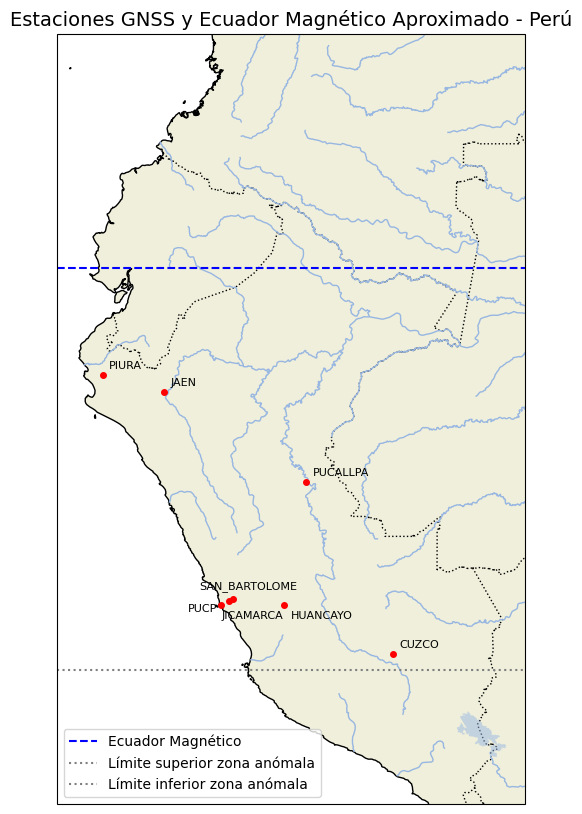

In [104]:
# Crear figura y mapa
fig = plt.figure(figsize=(10, 10))
ax = plt.axes(projection=ccrs.PlateCarree())

# Características físicas
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.RIVERS)
ax.add_feature(cfeature.LAKES, alpha=0.5)
ax.set_extent([-82, -68, -18, 5])  # Perú extendido al norte

# Dibujar estaciones
for nombre, (lat, lon) in ubicaciones.items():
    ax.plot(lon, lat, marker='o', color='red', markersize=4, transform=ccrs.PlateCarree())
    dx, dy = desplazamientos[nombre]
    ax.text(lon + dx, lat + dy, nombre, fontsize=8, transform=ccrs.PlateCarree())

# Dibujar ecuador magnético aproximado (línea recta)
longitudes = list(range(-82, -67))  # de oeste a este
lat_ecuador_magnetico = [ -2.0 ] * len(longitudes)  # Ecuador magnético aprox. Perú ~ -2°
lat_banda_anomala_norte = [ 10.0 ] * len(longitudes)
lat_banda_anomala_sur = [ -14.0 ] * len(longitudes)

ax.plot(longitudes, lat_ecuador_magnetico, linestyle='--', color='blue', label='Ecuador Magnético', transform=ccrs.PlateCarree())
ax.plot(longitudes, lat_banda_anomala_norte, linestyle=':', color='gray', label='Límite superior zona anómala', transform=ccrs.PlateCarree())
ax.plot(longitudes, lat_banda_anomala_sur, linestyle=':', color='gray', label='Límite inferior zona anómala', transform=ccrs.PlateCarree())

# Leyenda y título
plt.legend(loc='lower left')
plt.title("Estaciones GNSS y Ecuador Magnético Aproximado - Perú", fontsize=14)
plt.grid(True)
plt.show()

In [106]:
!pip install wmm2020

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 4.4 MB/s eta 0:00:00 MB/s eta 0:00:01:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 11.1 MB/s eta 0:00:00
  Created wheel for wmm2020: filename=wmm2020-1.1.1-py3-none-any.whl size=3183606 sha256=56fe53da719e1046007c33415764f74bb3392f111975429d2ef2524f6c962fe5
  Stored in directory: /home/soporte/.cache/pip/wheels/3f/84/cd/a6077b1e81ff6670606f219882dcfd62ed1358a7327fe5483c
Successfully built wmm2020
Note: you may need to restart the kernel to use updated packages.


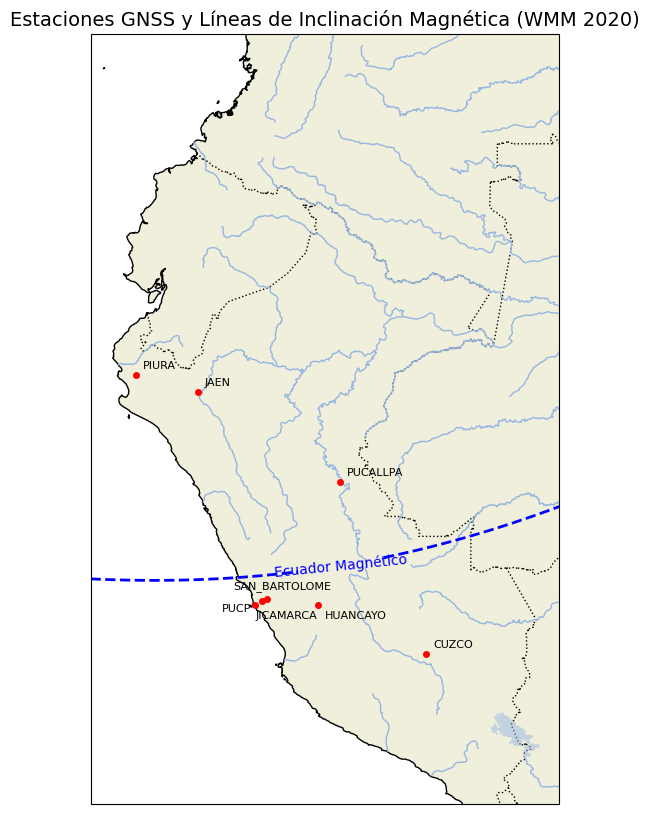

In [183]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from wmm2020 import wmm

# 1. Definir grilla sobre el Perú
lons = np.linspace(-82, -68, 200)
lats = np.linspace(-18, 5, 200)
lon_grid, lat_grid = np.meshgrid(lons, lats)

# 2. Calcular inclinación magnética (dip angle) en cada punto (altura 100 km)
inclination = np.zeros_like(lat_grid)
for i in range(lat_grid.shape[0]):
    for j in range(lat_grid.shape[1]):
        B = wmm(lat_grid[i, j], lon_grid[i, j], 0.100, 2025.0)
        inclination[i, j] = B['incl']  # <- aquí está la corrección

# 3. Estaciones GNSS
ubicaciones = {
    "CUZCO": (-13.5320, -71.9675),
    "JAEN": (-5.7082, -78.8024),
    "JICAMARCA": (-11.9500, -76.8700),
    "PIURA": (-5.1945, -80.6328),
    "HUANCAYO": (-12.0650, -75.2049),
    "SAN_BARTOLOME": (-11.8714, -76.7295),
    "PUCP": (-12.0682, -77.0803),
    "PUCALLPA": (-8.3791, -74.5539)
}

# Desplazamientos de texto para evitar sobreposición
desplazamientos = {
    "CUZCO": (0.2, 0.2),
    "JAEN": (0.2, 0.2),
    "JICAMARCA": (-0.2, -0.5),
    "PIURA": (0.2, 0.2),
    "HUANCAYO": (0.2, -0.4),
    "SAN_BARTOLOME": (-1.0, 0.3),
    "PUCP": (-1.0, -0.2),
    "PUCALLPA": (0.2, 0.2)
}
# 4. Graficar
fig = plt.figure(figsize=(10, 10))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.set_extent([-82, -68, -18, 5], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.RIVERS)
ax.add_feature(cfeature.LAKES, alpha=0.5)

# 1. Dibujar línea de inclinación = 0° (Ecuador Magnético)
cs0 = ax.contour(lon_grid, lat_grid, inclination, levels=[0], colors='blue', linewidths=2, linestyles='--')

# Verificamos si hay segmentos en la línea para evitar el error
if len(cs0.allsegs[0]) > 0:
    # Elegimos el primer segmento del contorno
    seg = cs0.allsegs[0][0]
    # Tomamos un punto medio (ajustar el índice para mover la etiqueta)
    label_point = seg[len(seg)//2]
    # Desplazamos el texto ligeramente hacia arriba en latitud
    manual_loc = [(label_point[0], label_point[1] + 1.5)]
    ax.clabel(cs0, fmt=lambda _: "Ecuador Magnético", inline=True, fontsize=10, manual=manual_loc)


# Dibujar estaciones
for nombre, (lat, lon) in ubicaciones.items():
    ax.plot(lon, lat, marker='o', color='red', markersize=4, transform=ccrs.PlateCarree())
    dx, dy = desplazamientos[nombre]
    ax.text(lon + dx, lat + dy, nombre, fontsize=8, transform=ccrs.PlateCarree())

# Título
plt.title("Estaciones GNSS y Líneas de Inclinación Magnética (WMM 2020)", fontsize=14)
plt.grid(True)
plt.show()

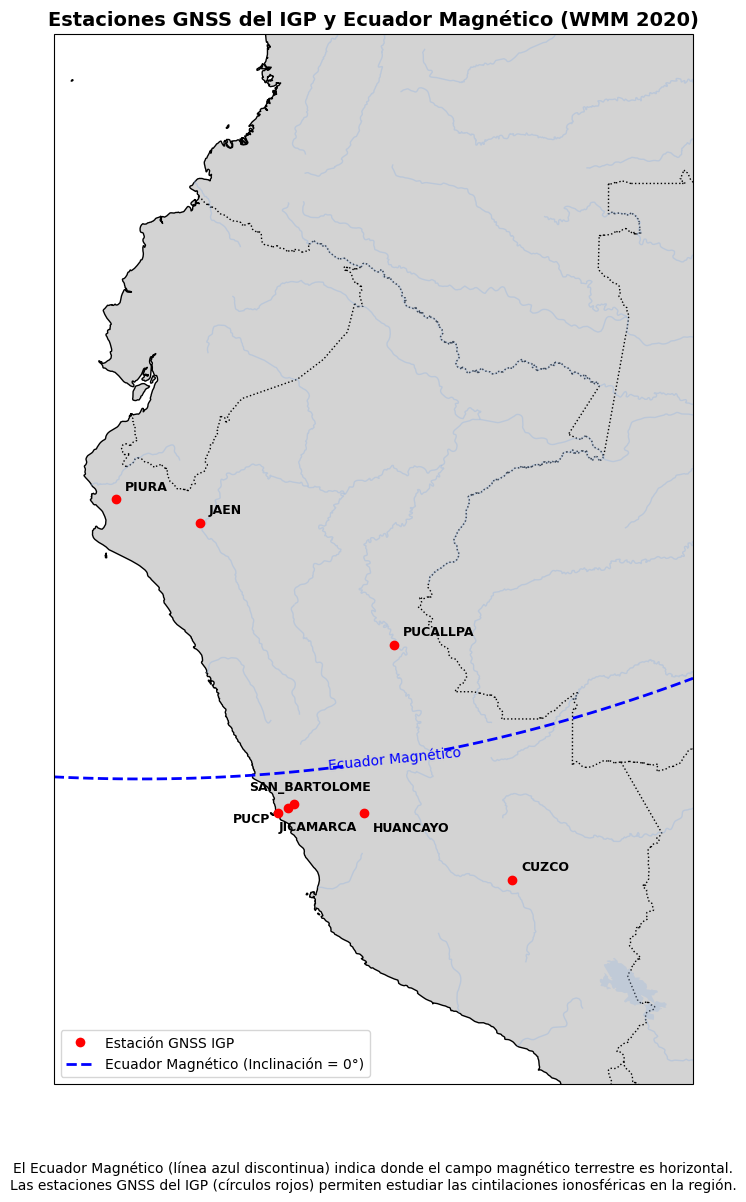

In [185]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from wmm2020 import wmm

# 1. Definir grilla sobre el Perú
lons = np.linspace(-82, -68, 200)
lats = np.linspace(-18, 5, 200)
lon_grid, lat_grid = np.meshgrid(lons, lats)

# 2. Calcular inclinación magnética (dip angle) en cada punto (altura 100 km)
inclination = np.zeros_like(lat_grid)
for i in range(lat_grid.shape[0]):
    for j in range(lat_grid.shape[1]):
        B = wmm(lat_grid[i, j], lon_grid[i, j], 0.100, 2025.0)
        inclination[i, j] = B['incl']

# 3. Estaciones GNSS
ubicaciones = {
    "CUZCO": (-13.5320, -71.9675),
    "JAEN": (-5.7082, -78.8024),
    "JICAMARCA": (-11.9500, -76.8700),
    "PIURA": (-5.1945, -80.6328),
    "HUANCAYO": (-12.0650, -75.2049),
    "SAN_BARTOLOME": (-11.8714, -76.7295),
    "PUCP": (-12.0682, -77.0803),
    "PUCALLPA": (-8.3791, -74.5539)
}
desplazamientos = {
    "CUZCO": (0.2, 0.2),
    "JAEN": (0.2, 0.2),
    "JICAMARCA": (-0.2, -0.5),
    "PIURA": (0.2, 0.2),
    "HUANCAYO": (0.2, -0.4),
    "SAN_BARTOLOME": (-1.0, 0.3),
    "PUCP": (-1.0, -0.2),
    "PUCALLPA": (0.2, 0.2)
}

# 4. Graficar
fig = plt.figure(figsize=(12, 12), dpi=100)
ax = plt.axes(projection=ccrs.PlateCarree())

# Agregar mapa base
ax.set_extent([-82, -68, -18, 5], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.RIVERS, alpha=0.4)
ax.add_feature(cfeature.LAKES, alpha=0.3)

# Dibujar línea de inclinación = 0° (Ecuador Magnético)
cs0 = ax.contour(lon_grid, lat_grid, inclination, levels=[0], colors='blue', linewidths=2, linestyles='--')

if len(cs0.allsegs[0]) > 0:
    seg = cs0.allsegs[0][0]
    label_point = seg[len(seg)//2]
    manual_loc = [(label_point[0], label_point[1] + 1.5)]
    ax.clabel(cs0, fmt=lambda _: "Ecuador Magnético", inline=True, fontsize=10, manual=manual_loc)

# Dibujar estaciones GNSS
for nombre, (lat, lon) in ubicaciones.items():
    ax.plot(lon, lat, marker='o', color='red', markersize=6, transform=ccrs.PlateCarree(), label='_nolegend_')
    dx, dy = desplazamientos[nombre]
    ax.text(lon + dx, lat + dy, nombre, fontsize=9, weight='bold', transform=ccrs.PlateCarree())

# Añadir leyenda personalizada
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Estación GNSS IGP',
           markerfacecolor='red', markersize=8),
    Line2D([0], [0], color='blue', lw=2, linestyle='--', label='Ecuador Magnético (Inclinación = 0°)')
]
ax.legend(handles=legend_elements, loc='lower left', fontsize=10, frameon=True)

# Título y anotación descriptiva
plt.title("Estaciones GNSS del IGP y Ecuador Magnético (WMM 2020)", fontsize=14, weight='bold')
plt.annotate(
    "El Ecuador Magnético (línea azul discontinua) indica donde el campo magnético terrestre es horizontal.\n"
    "Las estaciones GNSS del IGP (círculos rojos) permiten estudiar las cintilaciones ionosféricas en la región.",
    xy=(0.5, -0.1), xycoords='axes fraction', ha='center', fontsize=10
)

plt.tight_layout()
plt.grid(True)
plt.show()